# Segmentation Model

In [1]:
from torch import nn
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
from torchvision.models.segmentation import DeepLabV3_MobileNet_V3_Large_Weights

# --- 3. U-Net Completa ---
class SegmentationModel(nn.Module):
    def __init__(self, num_classes=9):
        super(SegmentationModel, self).__init__()

        # Carica modello con pesi pre-addestrati (su COCO)
        self.model = deeplabv3_mobilenet_v3_large(weights=DeepLabV3_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1)

        # Sostituisce la testa di classificazione con il numero desiderato di classi
        self.model.classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        return self.model(x)['out']

# Label Mapper

In [2]:
import numpy as np
from PIL import Image
import torch

class LabelMapper:
    def __init__(self):
        self.color_to_class_id_map = { # Renamed to avoid confusion
            (255, 255, 255): 0,   # Background
            (1, 88, 255): 1,      # Sky
            (156, 76, 30): 2,     # Rough Trail
            (178, 176, 153): 3,   # Smooth Trail
            (128, 255, 0): 4,     # Traversable grass
            (40, 80, 0): 5,       # High Vegetation
            (0, 160, 0): 6,       # Non Traversable Low Vegetation
            (255, 0, 128): 7,     # Puddle
            (255, 0, 0): 8        # Obstacle
        }
        # Optionally, for debugging/visualization:
        self.class_id_to_color = {v: k for k, v in self.color_to_class_id_map.items()}

    def rgb_to_class_id(self, rgb_pixel):
        # Converti il pixel in una tupla per la ricerca nel dizionario
        rgb_tuple = tuple(rgb_pixel)
        return self.color_to_class_id_map.get(rgb_tuple, 0) # Ritorna 0 (Background) se il colore non è mappato

    def class_id_to_rgb(self, class_id):
        return self.class_id_to_color.get(class_id)

    def color_to_class_id(self, labels_image: Image.Image) -> torch.Tensor:
        """
        Converts a PIL RGB image of labels to a PyTorch tensor of class IDs.
        Pixels with colors not defined in color_to_class_id_map will be mapped to 0 (Background).
        """
        labels_array = np.array(labels_image)
        height, width, _ = labels_array.shape
        class_id_map = np.zeros((height, width), dtype=np.int64)

        # Iterate through the color map and assign class IDs
        for color_tuple, class_id in self.color_to_class_id_map.items():
            # Create a boolean mask where the pixels match the current color
            match = np.all(labels_array == np.array(color_tuple).reshape(1, 1, 3), axis=2)
            class_id_map[match] = class_id

        return torch.from_numpy(class_id_map)

    def class_id_to_rgb_image(self, class_id_array: np.ndarray) -> np.ndarray:
        """
        Converts a NumPy array of class IDs to an RGB image array.
        """
        height, width = class_id_array.shape
        rgb_image_array = np.zeros((height, width, 3), dtype=np.uint8)

        for class_id, color_tuple in self.class_id_to_color.items():
            match = (class_id_array == class_id)
            rgb_image_array[match] = np.array(color_tuple)
        return rgb_image_array

# Image Processor

In [3]:
import torch

class ImageProcessor:
    def preprocess(self, image_batch_uint8):
        image_batch_float = image_batch_uint8.float() / 255.0
        return image_batch_float.permute(0, 3, 1, 2)

    def postprocess(self, prediction_tensor_float):
        predicted_classes = torch.nn.functional.softmax(prediction_tensor_float, dim=1)
        predicted_classes = torch.argmax(predicted_classes, dim=1)
        predicted_classes = predicted_classes.unsqueeze(-1).to(torch.int64)
        return predicted_classes

# Rural Dataset

In [4]:
from torch.utils.data import Dataset
import os

class RuralDataset(Dataset):
    def __init__(self, root_dir, transform=None, augmentation=False, num_augmentations=3):
        self.root_dir = root_dir
        self.transform = transform
        self.augmentation = augmentation
        self.num_augmentations = num_augmentations
        self.label_mapper = LabelMapper()
        self.samples = []
        self.mapper = np.full((256, 256, 256), 0, dtype=np.uint8)  # Default = background (0)
        for rgb, class_id in self.label_mapper.color_to_class_id_map.items():
            r, g, b = rgb
            self.mapper[r, g, b] = class_id

        # Caricamento percorsi immagini
        for folder_name in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, folder_name)
            if os.path.isdir(folder_path):
                rgb_path = os.path.join(folder_path, 'rgb.jpg')
                labels_path = os.path.join(folder_path, 'labels.png')
                if os.path.exists(rgb_path) and os.path.exists(labels_path):
                    self.samples.append((rgb_path, labels_path, False))
                    if augmentation:
                        for i in range(num_augmentations):
                            self.samples.append((rgb_path, labels_path, True))
                else:
                    print(f"Warning: Missing rgb.jpg or labels.png in {folder_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, labels_path, augmentation = self.samples[idx]

        # Caricamento immagini
        image = np.array(Image.open(rgb_path).convert("RGB"))
        mask = np.array(Image.open(labels_path).convert("RGB"))
        mask = self.mapper[
            mask[..., 0],
            mask[..., 1],
            mask[..., 2]
        ]

        # Applica le trasformazioni
        if self.transform and augmentation:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        elif self.transform:
            self.transform = A.Compose([
                t for t in self.transform.transforms if isinstance(t, (A.Resize, A.Normalize, ToTensorV2))
            ], additional_targets={'mask': 'mask'})
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = ToTensorV2()(image=image)['image']
            mask = torch.from_numpy(mask).long()

        return image, mask.long()

# Trainer

In [5]:
import torch
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
#from torch.optim.lr_scheduler import ReduceLROnPlateau

class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device, focal_loss, dice_loss, early_stopping_patience=10):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.image_processor = ImageProcessor()
        self.early_stopping_patience = early_stopping_patience
        self.num_labels = 9  # classi da 0 a 8 (0 = background)
        self.focal_loss = focal_loss
        self.dice_loss = dice_loss

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        running_focal = 0.0
        running_dice = 0.0
        with tqdm(self.train_loader, desc="Training", leave=True) as pbar:
            for batch_idx, (images, labels) in enumerate(pbar):
                images = images.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(images)
                if isinstance(outputs, dict):
                    outputs = outputs["out"]
                loss = self.criterion(outputs, labels)
                focal = self.focal_loss(outputs, labels).item()
                dice = self.dice_loss(outputs, labels).item()
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item()
                running_focal += focal
                running_dice += dice
                # Aggiorna la barra con la loss media corrente
                pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        avg_loss = running_loss / len(self.train_loader)
        avg_focal = running_focal / len(self.train_loader)
        avg_dice = running_dice / len(self.train_loader)
        return avg_loss, avg_focal, avg_dice

    def validate_epoch(self):
        self.model.eval()
        total_loss = 0.0
        total_focal = 0.0
        total_dice = 0.0
        all_predictions = []
        all_labels = []
        with torch.no_grad():
            with tqdm(self.val_loader, desc="Validation", leave=True) as pbar:
                for batch_idx, (images, labels) in enumerate(pbar):
                    images = images.to(self.device, non_blocking=True)
                    labels = labels.to(self.device, non_blocking=True)
                    outputs = self.model(images)
                    if isinstance(outputs, dict):
                        outputs = outputs["out"]
                    loss = self.criterion(outputs, labels)
                    focal = self.focal_loss(outputs, labels).item()
                    dice = self.dice_loss(outputs, labels).item()
                    total_loss += loss.item()
                    total_focal += focal
                    total_dice += dice
                    predictions = self.image_processor.postprocess(outputs)
                    all_predictions.append(predictions.cpu())
                    all_labels.append(labels.cpu())
                    # Aggiorna la barra con la loss media corrente
                    pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        avg_loss = total_loss / len(self.val_loader) if len(self.val_loader) > 0 else 0.0
        avg_focal = total_focal / len(self.val_loader) if len(self.val_loader) > 0 else 0.0
        avg_dice = total_dice / len(self.val_loader) if len(self.val_loader) > 0 else 0.0
        avg_iou = 0.0
        if len(all_predictions) > 0 and len(all_labels) > 0:
            concatenated_predictions = torch.cat(all_predictions).numpy()
            concatenated_labels = torch.cat(all_labels).numpy()
            concatenated_predictions = concatenated_predictions.squeeze(axis=-1)
            iou_scores_all_classes = self.compute_all_iou(concatenated_predictions, concatenated_labels)
            avg_ious_per_class = np.nan_to_num(iou_scores_all_classes)
            avg_iou = np.nanmean(iou_scores_all_classes)
        else:
            avg_ious_per_class = np.zeros(self.num_labels)
        print(f"Mean IoU by class: {[f'{iou:.4f}' for iou in avg_ious_per_class]}")

        return avg_iou, avg_loss, avg_focal, avg_dice

    def run(self, num_epochs, model_save_path):
        best_val_iou = float('-inf')
        epochs_no_improve = 0
        train_losses = []
        val_losses = []
        train_focal_losses = []
        val_focal_losses = []
        train_dice_losses = []
        val_dice_losses = []

        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch + 1}/{num_epochs}")

            train_loss, train_focal, train_dice = self.train_epoch()
            train_losses.append(train_loss)
            train_focal_losses.append(train_focal)
            train_dice_losses.append(train_dice)
            print(f"Train Loss: {train_loss:.4f}")

            val_iou, val_loss, val_focal, val_dice = self.validate_epoch()
            val_losses.append(val_loss)
            val_focal_losses.append(val_focal)
            val_dice_losses.append(val_dice)
            print(f"Validation mIoU: {val_iou:.4f}, Validation Loss: {val_loss:.4f}")

            if val_iou > best_val_iou:
                best_val_iou = val_iou
                torch.save(self.model.state_dict(), model_save_path)
                print(f"New best model saved in {model_save_path}")
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                print(f"No improvement for {epochs_no_improve} epochs.")

            if epochs_no_improve >= self.early_stopping_patience:
                print(f"Early stopping activated after {epoch + 1} epochs. Best mIoU: {best_val_iou:.4f}")
                break

        print(f"Best model (mIoU={best_val_iou:.4f}) saved in {model_save_path}")
        self.plot_losses(train_losses, val_losses, train_dice_losses, val_dice_losses, train_focal_losses, val_focal_losses)


    @staticmethod
    def compute_class_weights(dataloader, num_classes):
        label_counts = Counter()
        total_pixels = 0
        for _, masks in dataloader:
            for mask in masks:
                pixels = mask.cpu().numpy().flatten()
                label_counts.update(pixels.tolist())
                total_pixels += len(pixels)

        weights = [0.0] * num_classes
        for i in range(num_classes):
            count = label_counts.get(i, 1e-6)
            weights[i] = total_pixels / (count * num_classes)
        return torch.tensor(weights, dtype=torch.float32)

    @staticmethod
    def get_class_distribution(dataset):
        label_counts = Counter()
        for _, mask in dataset:
            label_counts.update(mask.numpy().flatten().tolist())
        return dict(sorted(label_counts.items()))

    def compute_iou(self, mask1, mask2, label):
        intersection = np.sum((mask1 == label) & (mask2 == label))
        union = np.sum((mask1 == label) | (mask2 == label))
        if union == 0:
            return np.nan
        return intersection / union

    def compute_all_iou(self, mask1, mask2, num_labels=8):
        iou_scores = np.zeros((num_labels))
        for label in range(num_labels):
            iou = self.compute_iou(mask1, mask2, label + 1)
            iou_scores[label] = iou
        return iou_scores

    def compute_all_iou_batch(self, preds, labels, num_labels):
        if preds.ndim == labels.ndim + 1 and preds.shape[-1] == 1:
            preds = preds.squeeze(axis=-1) # Remove the last dimension if its size is 1
        iou_scores = np.zeros(num_labels)
        for label in range(num_labels):
            pred_mask = (preds == label)
            label_mask = (labels == label)
            intersection = np.logical_and(pred_mask, label_mask).sum()
            union = np.logical_or(pred_mask, label_mask).sum()
            if union == 0:
                iou_scores[label] = np.nan
            else:
                iou_scores[label] = intersection / union
        return iou_scores

    def plot_losses(self, train_losses, val_losses, train_dice_losses, val_dice_losses, train_focal_losses, val_focal_losses):
        fig, axs = plt.subplots(3, 1, figsize=(10, 15))
        # Plot Loss
        axs[0].plot(train_losses, label='Training Loss')
        axs[0].plot(val_losses, label='Validation Loss')
        axs[0].set_xlabel('Epoch')
        axs[0].set_ylabel('Loss')
        axs[0].set_title('Training vs Validation Loss')
        axs[0].legend()
        axs[0].grid(True)
        # Plot Dice Loss
        axs[1].plot(train_dice_losses, label='Train Dice Loss')
        axs[1].plot(val_dice_losses, label='Validation Dice Loss')
        axs[1].set_xlabel('Epoch')
        axs[1].set_ylabel('Dice Loss')
        axs[1].set_title('Train vs Validation Dice Loss')
        axs[1].legend()
        axs[1].grid(True)
        # Plot Focal Loss
        axs[2].plot(train_focal_losses, label='Train Focal Loss')
        axs[2].plot(val_focal_losses, label='Validation Focal Loss')
        axs[2].set_xlabel('Epoch')
        axs[2].set_ylabel('Focal Loss')
        axs[2].set_title('Train vs Validation Focal Loss')
        axs[2].legend()
        axs[2].grid(True)
        plt.tight_layout()
        plt.show()


# Evaluator

In [6]:
import numpy as np
import torch

class Evaluator:
    def __init__(self, model, test_loader, device):
        self.model = model
        self.test_loader = test_loader
        self.device = device

    @staticmethod
    def calculate_iou_metric_single(prediction, ground_truth, num_classes=9):
        iou_per_class = []
        for cls in range(num_classes):
            pred_mask = (prediction == cls)
            gt_mask = (ground_truth == cls)
            intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
            union = torch.logical_or(pred_mask, gt_mask).sum().item()
            if union == 0:
                iou_per_class.append(1.0)
            else:
                iou_per_class.append(intersection / union)
        return iou_per_class

    def calculate_iou_metric(self, prediction, ground_truth, num_classes=9):
        def compute_iou(mask1, mask2, label):
            intersection = np.sum((mask1 == label) & (mask2 == label))
            union = np.sum((mask1 == label) | (mask2 == label))
            if union == 0:
                return np.nan
            return intersection / union
        def compute_all_iou(mask1, mask2, num_labels=8):
            iou_scores = np.zeros((num_labels))
            for label in range(num_labels):
                iou = compute_iou(mask1, mask2, label+1)
                iou_scores[label] = iou
            return iou_scores
        if not isinstance(prediction, np.ndarray):
            prediction = prediction.cpu().numpy() if hasattr(prediction, 'cpu') else np.array(prediction)
        if not isinstance(ground_truth, np.ndarray):
            ground_truth = ground_truth.cpu().numpy() if hasattr(ground_truth, 'cpu') else np.array(ground_truth)
        return compute_all_iou(prediction, ground_truth, num_labels=num_classes-1)

    def evaluate(self):
        self.model.eval()
        all_ious = []
        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                if isinstance(outputs, dict):
                    outputs = outputs["out"]
                predictions = torch.argmax(outputs, dim=1).cpu().numpy()
                labels = labels.cpu().numpy()
                for i in range(images.shape[0]):
                    iou = self.calculate_iou_metric(predictions[i], labels[i])
                    all_ious.append(iou)
        mean_iou_per_class = np.mean(all_ious, axis=0)
        overall_mean_iou = np.mean(mean_iou_per_class)
        return overall_mean_iou, mean_iou_per_class

    def evaluate_classification_metrics(self, num_classes=9):
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        self.model.eval()
        all_preds = []
        all_gts = []
        with torch.no_grad():
            for images, masks in self.test_loader:
                images = images.to(self.device)
                masks = masks.to(self.device)
                outputs = self.model(images)
                if isinstance(outputs, dict):
                    outputs = outputs["out"]
                preds = torch.argmax(outputs, dim=1)
                all_preds.append(preds.cpu().numpy().flatten())
                all_gts.append(masks.cpu().numpy().flatten())
        y_pred = np.concatenate(all_preds)
        y_true = np.concatenate(all_gts)
        metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'f1': f1_score(y_true, y_pred, average='macro', zero_division=0)
        }
        return metrics

    def compare_random_label_and_prediction(self, val_dataset):
        import random
        import os
        import matplotlib.pyplot as plt
        self.model.eval()
        label_mapper = LabelMapper()
        for images, labels in self.test_loader:
            idx = random.randint(0, images.shape[0] - 1)
            image = images[idx:idx + 1].to(self.device)
            label = labels[idx].cpu().numpy()
            output = self.model(image)
            if isinstance(output, dict):
                output = output["out"]
            pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
            break
        if hasattr(val_dataset, 'indices'):
            original_idx = val_dataset.indices[idx]
            folder_path = val_dataset.dataset.samples[original_idx][0]
        else:
            folder_path = val_dataset.samples[idx][0]
        folder_name = os.path.basename(os.path.dirname(folder_path))
        def mask_to_rgb(mask):
            h, w = mask.shape
            rgb = np.zeros((h, w, 3), dtype=np.uint8)
            for cls in np.unique(mask):
                rgb[mask == cls] = label_mapper.class_id_to_rgb(cls)
            return rgb
        label_rgb = mask_to_rgb(label)
        pred_rgb = mask_to_rgb(pred)
        plt.figure(figsize=(10, 5))
        plt.suptitle(f"Folder origine: {folder_name}")
        plt.subplot(1, 2, 1)
        plt.title("Label reale")
        plt.imshow(label_rgb.astype(np.uint8))
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.title("Predizione")
        plt.imshow(pred_rgb.astype(np.uint8))
        plt.axis('off')
        plt.show()

    def compute_iou(self, mask1, mask2, label):
        intersection = np.sum((mask1 == label) & (mask2 == label))
        union = np.sum((mask1 == label) | (mask2 == label))
        if union == 0:
            return np.nan
        return intersection / union

    def compute_all_iou(self, mask1, mask2, num_labels=8):
        iou_scores = np.zeros((num_labels))
        for label in range(num_labels):
            iou = self.compute_iou(mask1, mask2, label + 1)
            iou_scores[label] = iou
        return iou_scores

    def predict_from_folder(self, folder_number, data_root='train'):
        import os
        import matplotlib.pyplot as plt
        from PIL import Image
        from torchvision import transforms
        folder_name = f"{int(folder_number):04d}"
        folder_path = os.path.join(data_root, folder_name)
        rgb_path = os.path.join(folder_path, 'rgb.jpg')
        label_path = os.path.join(folder_path, 'labels.png')
        if not (os.path.exists(rgb_path) and os.path.exists(label_path)):
            print(f"Immagini non trovate in {folder_path}")
            return
        image = Image.open(rgb_path).convert("RGB")
        label_image = Image.open(label_path).convert("RGB")
        label_np = np.array(label_image)
        label_mapper = LabelMapper()
        class_id_mask = np.zeros((label_np.shape[0], label_np.shape[1]), dtype=np.uint8)
        for r in range(label_np.shape[0]):
            for c in range(label_np.shape[1]):
                pixel_rgb = tuple(label_np[r, c])
                class_id_mask[r, c] = label_mapper.rgb_to_class_id(pixel_rgb)
        class_id_mask = np.array(Image.fromarray(class_id_mask).resize((512, 512), resample=Image.NEAREST))
        val_transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        image_tensor = val_transform(image).unsqueeze(0).to(self.device)
        self.model.eval()
        with torch.no_grad():
            output = self.model(image_tensor)
            if isinstance(output, dict):
                output = output["out"]
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        def id_to_rgb_mask(id_mask, id_to_color_map):
            h, w = id_mask.shape
            rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
            for class_id, color_rgb in id_to_color_map.items():
                rgb_mask[id_mask == class_id] = color_rgb
            return rgb_mask

        id_to_color = label_mapper.class_id_to_color
        true_label_rgb = id_to_rgb_mask(class_id_mask, id_to_color)
        pred_label_rgb = id_to_rgb_mask(pred_mask, id_to_color)
        plt.figure(figsize=(18, 6))
        plt.subplot(1, 3, 1)
        plt.title('Immagine RGB')
        plt.imshow(image)
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.title('Label reale')
        plt.imshow(true_label_rgb)
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.title('Label predetta')
        plt.imshow(pred_label_rgb)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        correct = (pred_mask == class_id_mask).sum()
        total = class_id_mask.size
        print(f"Pixel classificati correttamente: {correct} / {total} ({correct / total:.2%})")
        iou_scores = self.compute_all_iou(pred_mask, class_id_mask, num_labels=8)
        mean_iou = np.nanmean(iou_scores)
        print(f"IoU medio sull'immagine: {mean_iou:.4f}")
        print(f"IoU per classe: {iou_scores}")

    def predict_from_all_folders(self, data_root='test'):
        import os
        import numpy as np
        from PIL import Image
        from torchvision import transforms
        import torch
        import matplotlib.pyplot as plt
        label_mapper = LabelMapper()
        all_iou_scores = []
        all_accuracies = []
        folders = [f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))]
        folders.sort()
        for folder_name in folders:
            folder_path = os.path.join(data_root, folder_name)
            rgb_path = os.path.join(folder_path, 'rgb.jpg')
            label_path = os.path.join(folder_path, 'labels.png')
            if not (os.path.exists(rgb_path) and os.path.exists(label_path)):
                print(f"Immagini non trovate in {folder_path}")
                continue
            image = Image.open(rgb_path).convert("RGB")
            label_image = Image.open(label_path).convert("RGB")
            label_np = np.array(label_image)
            class_id_mask = np.zeros((label_np.shape[0], label_np.shape[1]), dtype=np.uint8)
            for r in range(label_np.shape[0]):
                for c in range(label_np.shape[1]):
                    pixel_rgb = tuple(label_np[r, c])
                    class_id_mask[r, c] = label_mapper.rgb_to_class_id(pixel_rgb)
            class_id_mask = np.array(Image.fromarray(class_id_mask).resize((512, 512), resample=Image.NEAREST))
            val_transform = transforms.Compose([
                transforms.Resize((512, 512)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
            image_tensor = val_transform(image).unsqueeze(0).to(self.device)
            self.model.eval()
            with torch.no_grad():
                output = self.model(image_tensor)
                if isinstance(output, dict):
                    output = output["out"]
                pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
            correct = (pred_mask == class_id_mask).sum()
            total = class_id_mask.size
            accuracy = correct / total
            iou_scores = self.compute_all_iou(pred_mask, class_id_mask, num_labels=8)
            mean_iou = np.nanmean(iou_scores)
            all_iou_scores.append(iou_scores)
            all_accuracies.append(accuracy)
            print(f"Cartella: {folder_name}")
            print(f"  Pixel classificati correttamente: {correct} / {total} ({accuracy:.2%})")
            print(f"  IoU medio sull'immagine: {mean_iou:.4f}")
            print(f"  IoU per classe: {iou_scores}")

            # --- PLOT ---
            def id_to_rgb_mask(id_mask, id_to_color_map):
                h, w = id_mask.shape
                rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
                for class_id, color_rgb in id_to_color_map.items():
                    rgb_mask[id_mask == class_id] = color_rgb
                return rgb_mask

            id_to_color = label_mapper.class_id_to_color
            true_label_rgb = id_to_rgb_mask(class_id_mask, id_to_color)
            pred_label_rgb = id_to_rgb_mask(pred_mask, id_to_color)
            plt.figure(figsize=(18, 6))
            plt.suptitle(f"Risultati cartella: {folder_name}")
            plt.subplot(1, 3, 1)
            plt.title('Immagine RGB')
            plt.imshow(image)
            plt.axis('off')
            plt.subplot(1, 3, 2)
            plt.title('Label reale')
            plt.imshow(true_label_rgb)
            plt.axis('off')
            plt.subplot(1, 3, 3)
            plt.title('Label predetta')
            plt.imshow(pred_label_rgb)
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        if all_iou_scores:
            all_iou_scores = np.array(all_iou_scores)
            mean_iou_per_class = np.nanmean(all_iou_scores, axis=0)
            mean_iou_total = np.nanmean(all_iou_scores)
            mean_accuracy = np.mean(all_accuracies)
            print("\n--- Risultati medi su tutte le cartelle ---")
            print(f"Accuratezza media: {mean_accuracy:.2%}")
            print(f"IoU medio totale: {mean_iou_total:.4f}")
            print(f"IoU medio per classe: {mean_iou_per_class}")
        else:
            print("Nessuna cartella valida trovata.")


# Predictor

In [7]:
class Predictor:
    def __init__(self, model_path):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = SegmentationModel(num_classes=9).to(self.device)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.eval()
        self.processor = ImageProcessor() # Instantiate the processor for internal use

    def predict(self, X):
        # X: (batch_size, rows, cols, 3) uint8 [cite: 15]
        # Must perform all required preprocessing on the batch
        X_tensor = torch.from_numpy(X).to(self.device) # Convert numpy array to tensor
        preprocessed_X = self.processor.preprocess(X_tensor) # Preprocessing

        with torch.no_grad():
            outputs = self.model(preprocessed_X)

        # Must perform all required postprocessing on the results
        predictions = self.processor.postprocess(outputs) # Postprocessing

        # Return value: (batch_size, rows, cols, 1) uint8
        return predictions.cpu().numpy() # Convert back to numpy for return

# Main

In [8]:
torch.cuda.empty_cache()
from torch.nn import CrossEntropyLoss
from segmentation_models_pytorch.losses import DiceLoss, FocalLoss
from torch.utils.data import DataLoader

DATA_ROOT = 'train'
BATCH_SIZE = 4
LEARNING_RATE = 0.0001
NUM_EPOCHS = 20
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define Albumentations transformations
train_albumentations_transform = A.Compose([
    A.RandomResizedCrop(size=(512, 512), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.Affine(translate_percent=(0.05, 0.05), scale=(0.95, 1.05), shear=5, p=0.5),
    A.Perspective(scale=(0.01, 0.1), p=0.3),
    A.GaussianBlur(blur_limit=5, sigma_limit=(0.1, 2.0), p=0.5),
    A.Resize(height=512, width=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

val_albumentations_transform = A.Compose([
    A.Resize(height=512, width=512),  # Forza la dimensione a 256x256
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

In [10]:
from torch.utils.data import random_split, Subset, DataLoader

augmented_dataset = RuralDataset(root_dir=DATA_ROOT, transform=train_albumentations_transform, augmentation=True)
dataset = RuralDataset(root_dir=DATA_ROOT, transform=None, augmentation=False)

train_size = int(0.8 * len(dataset))  # es. 744
val_size = len(dataset) - train_size  # es. 187


train_indices, val_indices = random_split(range(len(dataset)), [train_size, val_size])

all_train_indices = []
for idx in train_indices:

    base = idx * 3
    all_train_indices.extend([base + i for i in range(3)])

train_dataset = Subset(augmented_dataset, all_train_indices)

val_dataset_full = RuralDataset(root_dir=DATA_ROOT, transform=val_albumentations_transform, augmentation=False)
val_dataset = Subset(val_dataset_full, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=0, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=0, shuffle=False, pin_memory=True)

print(f"Total samples: {len(dataset)}")

print("Numero di immagini originali nel train set:", len(train_indices))
print("Numero di immagini trasformate nel train set:", len(train_dataset) - len(train_indices))

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Total samples: 870
Numero di immagini originali nel train set: 696
Numero di immagini trasformate nel train set: 1392
Training samples: 2088
Validation samples: 174


In [11]:
model = SegmentationModel()
model.to(device)

print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (model): DeepLabV3(
    (backbone): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(

In [12]:
focal_loss = FocalLoss(mode='multiclass', gamma=2.0)
dice_loss = DiceLoss(mode='multiclass')
def combined_loss(pred, target):
    return 0.3*(focal_loss(pred, target)) + 0.7*(dice_loss(pred, target))

criterion = combined_loss
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


Starting training...

Epoch 1/20


Training: 100%|██████████| 522/522 [00:44<00:00, 11.86it/s, loss=0.4759]


Train Loss: 0.4289


Validation: 100%|██████████| 44/44 [00:02<00:00, 17.22it/s, loss=0.5441]


Mean IoU by class: ['0.8791', '0.6268', '0.6221', '0.5428', '0.8048', '0.4671', '0.0000', '0.2743']
Validation mIoU: 0.5271, Validation Loss: 0.3254
New best model saved in saved_model.pth

Epoch 2/20


...

Mean IoU by class: ['0.9186', '0.7663', '0.8138', '0.6938', '0.8762', '0.6900', '0.8451', '0.7886']
Validation mIoU: 0.7990, Validation Loss: 0.2079
No improvement for 2 epochs.

Epoch 20/20


Training: 100%|██████████| 522/522 [00:45<00:00, 11.40it/s, loss=0.1120]


Train Loss: 0.0640


Validation: 100%|██████████| 44/44 [00:02<00:00, 17.06it/s, loss=0.4702]


Mean IoU by class: ['0.9117', '0.7861', '0.8340', '0.6910', '0.8753', '0.7149', '0.8114', '0.7992']
Validation mIoU: 0.8030, Validation Loss: 0.2037
No improvement for 3 epochs.
Best model (mIoU=0.8090) saved in saved_model.pth


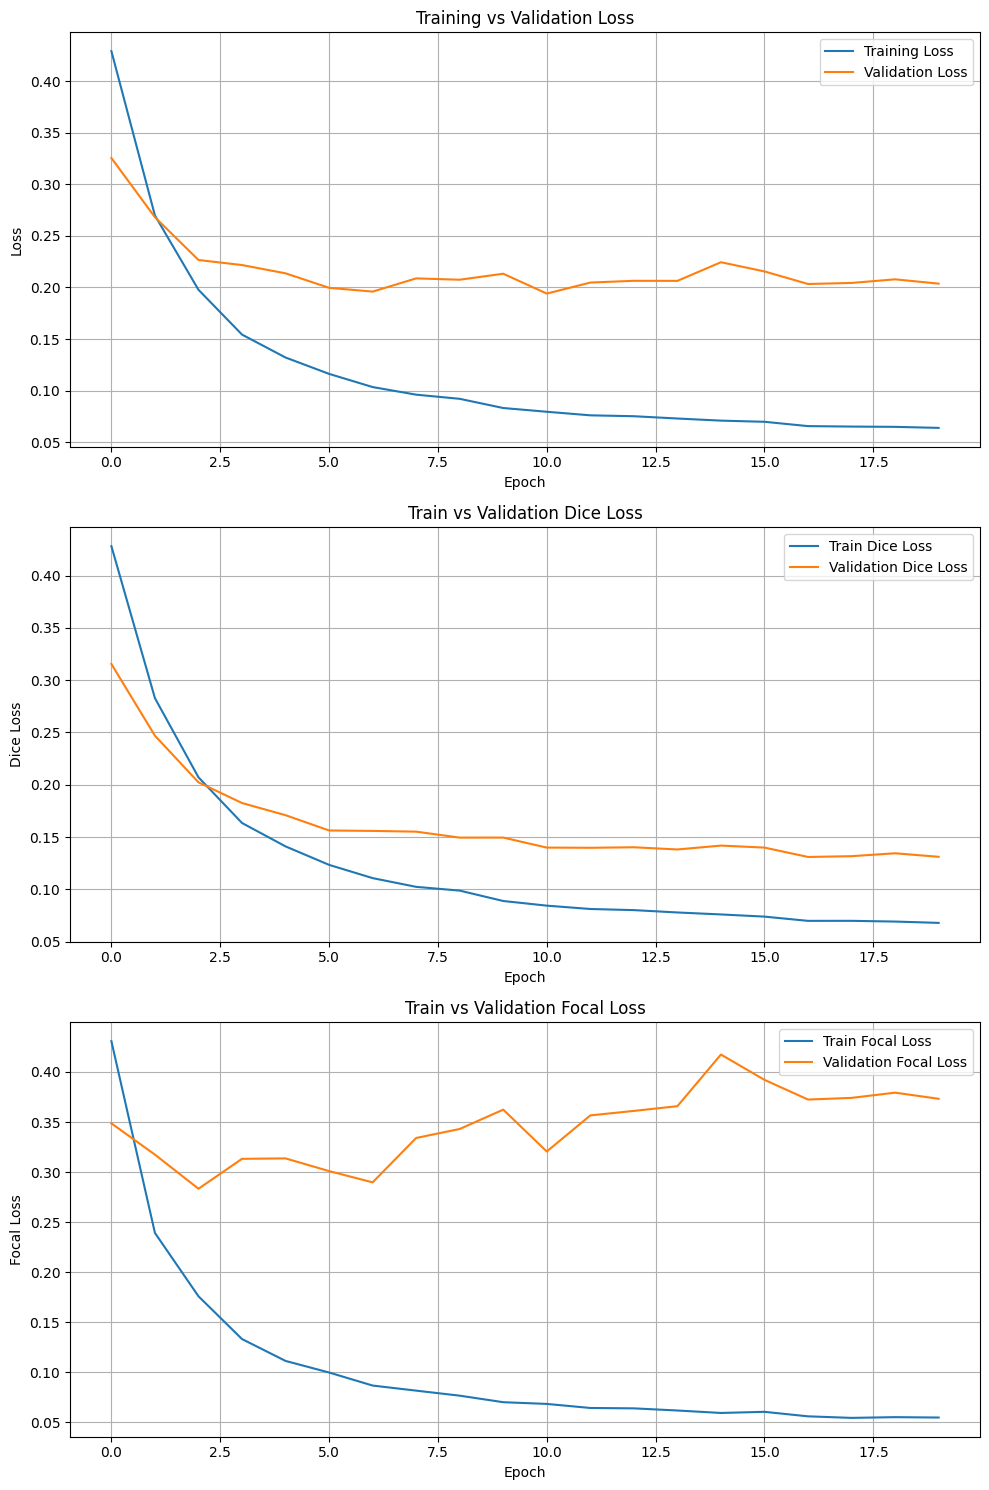

Training finished.


In [13]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device, focal_loss, dice_loss)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")

In [14]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.to(device)

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()
print(metrics)

{'accuracy': 0.9038163766093638, 'precision': 0.8793189125529205, 'recall': 0.9109094886025788, 'f1': 0.8939345595642434}


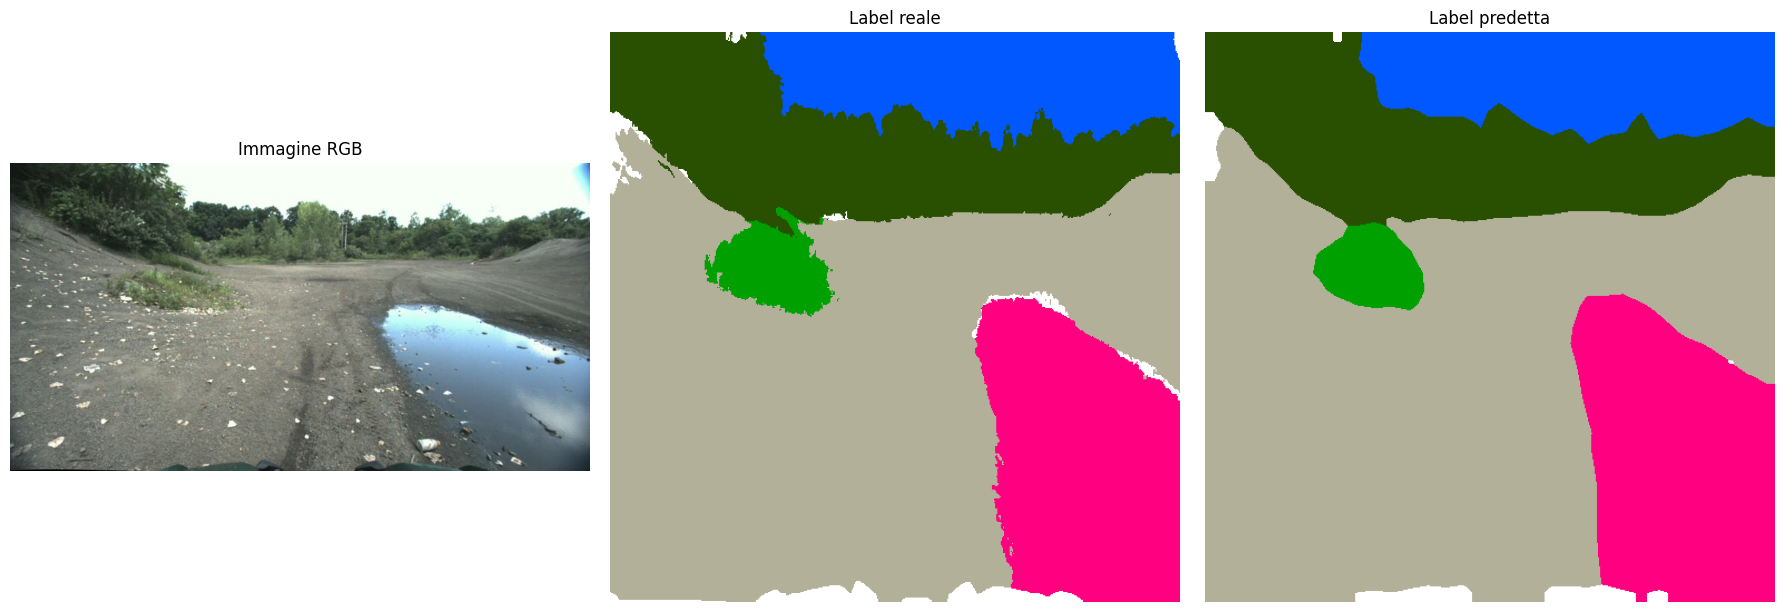

Pixel classificati correttamente: 255738 / 262144 (97.56%)
IoU medio sull'immagine: 0.9270
IoU per classe: [0.95602425        nan 0.97159394        nan 0.94976934 0.78894914
 0.9686831         nan]


In [15]:
evaluator.predict_from_folder(folder_number = 511, data_root = 'train')

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from torchvision import transforms

processor = ImageProcessor()
label_mapper = LabelMapper()

def predict(model, image_numpy):
    import torch
    from PIL import Image
    import numpy as np
    from torchvision import transforms
    model.eval()
    with torch.no_grad():
        image_pil = Image.fromarray(image_numpy).convert("RGB")
        val_transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        image_tensor = val_transform(image_pil).unsqueeze(0).to(model.device if hasattr(model, 'device') else 'cpu')
        output = model(image_tensor)
        if isinstance(output, dict):
            output = output["out"]

        pred_mask = torch.nn.functional.softmax(output, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1).squeeze(0).cpu().numpy()
        pred_mask_resized = np.array(Image.fromarray(pred_mask.astype(np.uint8)).resize((1024, 544), resample=Image.NEAREST))
    return pred_mask_resized


import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Metrics
def compute_iou(mask1, mask2, label):
  intersection = np.sum((mask1 == label) & (mask2 == label))
  union = np.sum((mask1 == label) | (mask2 == label))
  if union == 0:
    return np.nan
  return intersection / union
def compute_all_iou(mask1, mask2, num_labels=8):
  iou_scores = np.zeros((num_labels))
  for label in range(num_labels):
    iou = compute_iou(mask1, mask2, label+1) # we skip the background label
    iou_scores[label] = iou
  return iou_scores


# Run YOUR LOAD_MODEL FUNCTION
model = SegmentationModel(NUM_CLASSES) # Create an instance of your model class
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Main loop
test_dir = "test"  # we will change this path with that of the private test set directory
samples = os.listdir(test_dir)
IOUs = np.zeros((len(samples), 8))
verbose = True

for i, subdir in tqdm(enumerate(samples), desc="Processing samples"):
    subdir_path = os.path.join(test_dir, subdir)

    if os.path.isdir(subdir_path):
        # Get the data paths
        rgb_path = os.path.join(subdir_path, 'rgb.jpg')
        labels_path = os.path.join(subdir_path, 'labels.png')

        if os.path.exists(rgb_path) and os.path.exists(labels_path):
            if verbose:
                print(f"Processing subdirectory: {subdir}")

            try:  # ATTENTION: any error occurring in this try-catch means that the corresponding IOUs are evaluated as ZERO

                # Open images
                rgb_image = Image.open(rgb_path)
                rgb_array = np.asarray(rgb_image).copy()
                labels_image = Image.open(labels_path).convert("RGB")
                labels_array = label_mapper.color_to_class_id(labels_image).numpy()

                if verbose:
                    print(f"  Loaded {rgb_path} and {labels_path}")

                # Run YOUR PREDICT FUNCTION
                predicted_labels_array = predict(model, rgb_array)

                # Evaluate the IOU metric
                IOUs[i,:] = compute_all_iou(labels_array, predicted_labels_array)

                if verbose:
                    labels_vals = np.unique(np.asarray(labels_image))
                    print(f"  Unique labels values: {np.unique(labels_array)}")
                    predicted_labels_vals = np.unique(np.asarray(predicted_labels_array))
                    print(f"  Unique predicted labels values: {predicted_labels_vals}")

                    plt.subplot(1, 3, 1)
                    plt.imshow(rgb_image)
                    plt.subplot(1, 3, 2)
                    plt.imshow(labels_image)
                    plt.subplot(1, 3, 3)
                    plt.imshow(predicted_labels_array)
                    plt.show()

                rgb_image.close()
                labels_image.close()

            except FileNotFoundError:
                print(f"  Error: Could not find image files in {subdir_path}")
            except Exception as e:
                print(f"  Error processing images in {subdir_path}: {e}")
        else:
            print(f"  Skipping subdirectory {subdir}: rgb.jpg or labels.png not found.")

score = np.nanmean(IOUs)
print(f"\nFinal competition score: {score}")
